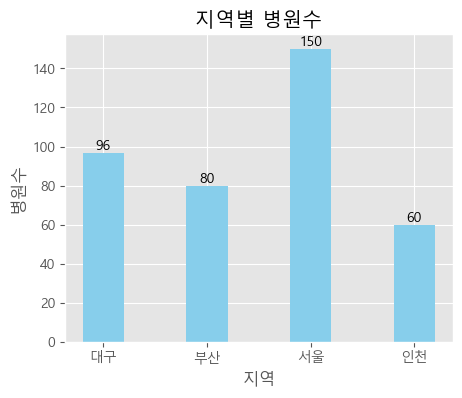

In [22]:
#반드시 pandas는 import해서 사용

import pandas as pd
# matplotlib 매트플롯립도 반드시 import해서 사용한다.
import matplotlib.pyplot as plt

#epdlxj todtjdgkrl
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    "총인구":[1000000,300000,200000]
})

df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    "병원수":[150,80,60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하여 df1, df2합집합이 된다
merged = pd.merge(df1, df2, on="지역",how="outer")

#결측치 처리를 진행한다.
#결측치는 병원수와, 총인구의 평균으로 정의한다
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged

#--------------------------------------

#반드시 한글 깨짐 현상 코드를 삽입한다.

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#차트 배경+
plt.style.use('ggplot')

#---------------------------------------
# 세로 막대 그래프 만들기 : plt.bar(x,y)
# x축 : 지역, y축 : 병원수
#---------------------------------------
#그래프 크기 지정 : figure(10,6)
plt.figure(figsize=(5,4))

# 세로 막대의 기본 넓이가 0.8이다
bars = plt.bar(merged["지역"],merged['병원수'],width=0.4,color='skyblue')

#차트제목, 가로축 제목, 세로축 제목
plt.title("지역별 병원수")
plt.xlabel("지역")
plt.ylabel("병원수")

# 세로 막대 각각의 데이터 레이블 값 출력하는 방법
for bar in bars:
    height = bar.get_height() # 막대 높이 추출하는 함수 예) 대구 : 96
    # bar.get_x() : 막대그래프 넓이의 시작점 추출 , bar.get_width() : 막대그래프 넓이전체  추출
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',ha = 'center',va='bottom') 



#반드시 저장이 먼저이다
plt.savefig('hospital_chart.png',dpi=300)

plt.show()


0번째 병원수 : 96.66666666666667
1번째 병원수 : 80.0
2번째 병원수 : 150.0
3번째 병원수 : 60.0


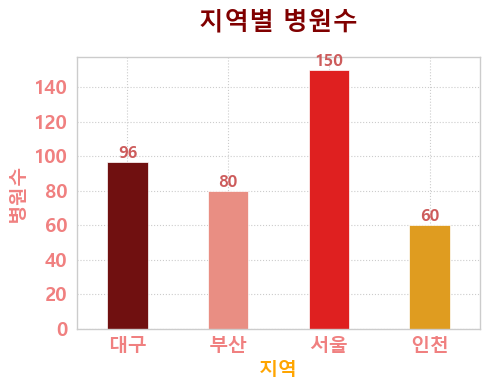

In [30]:
#반드시 pandas는 import해서 사용

import pandas as pd
# matplotlib 매트플롯립도 반드시 import해서 사용한다.
import matplotlib.pyplot as plt
# seaborn : matpltlib 기반위에서 차트 이쁘게 꾸미는 도구
import seaborn as sns


#epdlxj todtjdgkrl
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    "총인구":[1000000,300000,200000]
})

df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    "병원수":[150,80,60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하여 df1, df2합집합이 된다
merged = pd.merge(df1, df2, on="지역",how="outer")

#결측치 처리를 진행한다.
#결측치는 병원수와, 총인구의 평균으로 정의한다
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged

#--------------------------------------

#반드시 한글 깨짐 현상 코드를 삽입한다.

# seaborn 스타일 지정
sns.set_style('whitegrid') # 배경스타일 설정, dark : 그리드 없이 배경이 어두워짐
sns.set_palette('pastel') # 색상 스타일 지정, deep: 진하게

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#차트 배경+
#plt.style.use('ggplot')

#---------------------------------------
# 세로 막대 그래프 만들기 : plt.bar(x,y)
# x축 : 지역, y축 : 병원수
#---------------------------------------
#그래프 크기 지정 : figure(10,6)
plt.figure(figsize=(5,4))

# 세로 막대의 기본 넓이가 0.8이다
#bars = plt.bar(merged["지역"],merged['병원수'],width=0.4,color='skyblue')
ax = sns.barplot(x='지역',y='병원수',hue='지역',data=merged,width=0.4,palette=['maroon','salmon','red','orange'],legend=False)


#차트제목, 가로축 제목, 세로축 제목
#pad 차트 제목여백
plt.title("지역별 병원수", fontsize = 18,fontweight='bold',color="maroon",pad=20)
plt.xlabel("지역", fontsize = 14,fontweight='bold',color="orange")
plt.ylabel("병원수", fontsize = 14,fontweight='bold',color="lightcoral")

# x축의 눈금의 값 각종 글꼴 지정하기
plt.xticks(fontsize = 14,fontweight='bold',color="lightcoral")
plt.yticks(fontsize = 14,fontweight='bold',color="lightcoral")

# 세로 막대 각각의 데이터 레이블 값 출력하는 방법
# for bar in bars:
#     height = bar.get_height() # 막대 높이 추출하는 함수 예) 대구 : 96
#     # bar.get_x() : 막대그래프 넓이의 시작점 추출 , bar.get_width() : 막대그래프 넓이전체  추출
#     plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',ha = 'center',va='bottom') 

for i in range(len(merged['병원수'])):
    v = merged['병원수'][i] # i번째 병원수 값 출력
    print(f'{i}번째 병원수 : {v}')
    ax.text(
        i, # x의 위치(막대위치 : 0,1,2~)
        v, # y의 위치 (막대높이)
        int(v),# 정수로 표시할 값
        ha='center',
        va='bottom',
        fontsize = 12,
        fontweight='bold',
        color="indianred"
    )

# 차트 그리드 선모양 지정하는 방법
# plt.grid(linestyle='--') 점선
# plt.grid(linestyle=':') 촘촘한 선
# plt.grid(linestyle='-.') 점+ 선 혼합
plt.grid(linestyle=':')

#반드시 저장이 먼저이다
#plt.savefig('hospital_chart.png',dpi=300)

# 그래프의 요소들의 겹치지 않게 자동으로 간격을 조정해주는 함수
plt.tight_layout()

plt.show()
